# Efficient Frontier and Max Sharpe Ratio



**Author:** DeShan Wilson  
**Date:** 2026-03-25  
**Data:** Yahoo Finance via yfinance (monthly, 2015–2025)  
**Assets:** SPY, AGG, GLD, VNQ, EFA  


Constructing an efficient frontier using Modern Portfolio Theory and identify the 
maximum Sharpe ratio portfolio across five asset class ETFs representing U.S. 
equities, bonds, gold, real estate, and international equities.

In [2]:
!pip install yfinance

In [2]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# Create plots folder
os.makedirs("plots", exist_ok=True)

In [3]:
# define assets and date range
tickers = ['SPY', 'AGG', 'GLD', 'VNQ', 'EFA']
start_date = '2015-01-01'
end_date = '2025-12-31'

# pull adj. close prices w/ yfinance

raw = yf.download(tickers, start = start_date, end = end_date, interval = '1mo')
prices = raw['Close']



[*********************100%***********************]  5 of 5 completed


In [4]:
prices.head()

Ticker,AGG,EFA,GLD,SPY,VNQ
Date,,,,,
2015-01-01,82.892448,44.243149,123.449997,165.172745,55.908676
2015-02-01,82.022064,47.047192,116.160004,174.456177,53.854496
2015-03-01,82.320656,46.375092,113.660004,170.953156,54.461693
2015-04-01,82.036781,48.066193,113.470001,173.404892,51.583527
2015-05-01,81.680832,48.160141,114.099998,175.634201,51.427582


In [5]:
prices.tail()

Ticker,AGG,EFA,GLD,SPY,VNQ
Date,,,,,
2025-08-01,96.898087,89.851845,318.070007,639.624573,90.541222
2025-09-01,97.995644,91.708206,355.470001,660.576782,89.736320
2025-10-01,98.603317,92.808273,368.119995,678.198303,88.373665
2025-11-01,99.199509,93.495819,387.880005,679.520813,90.514130
2025-12-01,98.595291,94.320862,396.309998,678.059143,87.689903


In [6]:
prices.shape

(132, 5)

In [7]:
# calculate monthly returns
returns = prices.pct_change().dropna()

In [8]:
returns.head()

Ticker,AGG,EFA,GLD,SPY,VNQ
Date,,,,,
2015-02-01,-0.010500,0.063378,-0.059052,0.056204,-0.036742
2015-03-01,0.003640,-0.014286,-0.021522,-0.020080,0.011275
2015-04-01,-0.003448,0.036466,-0.001672,0.014342,-0.052848
2015-05-01,-0.004339,0.001955,0.005552,0.012856,-0.003023
2015-06-01,-0.010778,-0.047269,-0.015162,-0.025054,-0.056229


In [9]:
returns.shape

(131, 5)

In [10]:
# summary statistics

returns.describe()

Ticker,AGG,EFA,GLD,SPY,VNQ
count,131.000000,131.000000,131.000000,131.000000,131.000000
mean,0.001430,0.006773,0.009773,0.011805,0.004773
std,0.014554,0.044337,0.041237,0.044074,0.051442
min,-0.041550,-0.141067,-0.083566,-0.129987,-0.200160
25%,-0.006018,-0.022256,-0.017928,-0.010204,-0.027272
50%,0.000951,0.011273,0.003563,0.015374,0.010731
75%,0.008934,0.033873,0.034289,0.036384,0.034509
max,0.045648,0.142694,0.117584,0.133610,0.131911


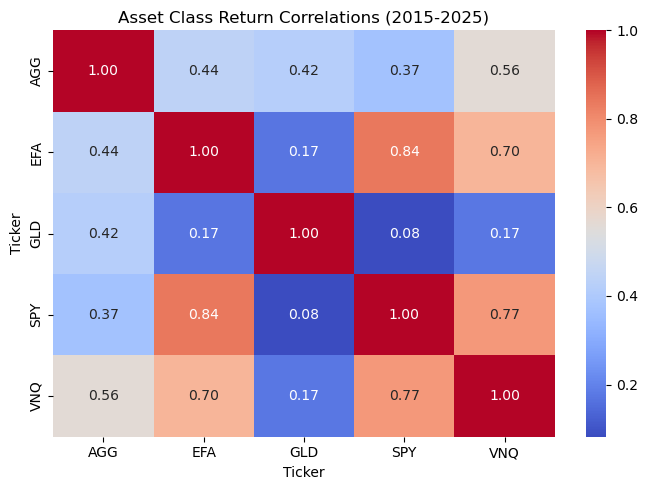

In [11]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Class Return Correlations (2015-2025)")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150)
plt.show()

In [12]:
# Annualized returns w/ covariance matrix

mean_returns = returns.mean() * 12
cov_matrix = returns.cov() * 12

# 3 month T-bill rate on December 31, 2025
risk_free = 0.0357

print(mean_returns)


Ticker
AGG    0.017162
EFA    0.081280
GLD    0.117273
SPY    0.141665
VNQ    0.057280
dtype: float64


In [13]:
# Simulate random portfolios
np.random.seed(42)
n_portfolios = 10000
n_assets     = len(tickers)

# Arrays to store results
port_returns  = np.zeros(n_portfolios)
port_vols     = np.zeros(n_portfolios)
port_sharpes  = np.zeros(n_portfolios)
port_weights  = np.zeros((n_portfolios, n_assets))

for i in range(n_portfolios):
    # Generate random weights
    weights = np.random.random(n_assets)
    weights /= weights.sum()

    # Portfolio return and volatility
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Results
    port_returns[i] = ret
    port_vols[i]    = vol
    port_sharpes[i] = (ret - risk_free) / vol
    port_weights[i] = weights

# Simulated max Sharpe portfolio
max_sharpe_idx = port_sharpes.argmax()
max_sharpe_ret = port_returns[max_sharpe_idx]
max_sharpe_vol = port_vols[max_sharpe_idx]

In [14]:
port_returns.shape

(10000,)

In [15]:

# Max Sharpe 0.84
port_sharpes.max()

np.float64(0.8387752443430117)

In [16]:
# Maximum Sharpe ratio portfolio details
print("Maximum Sharpe Ratio Portfolio")
print(f"Return:     {max_sharpe_ret:.4f}")
print(f"Volatility: {max_sharpe_vol:.4f}")
print(f"Sharpe:     {port_sharpes[max_sharpe_idx]:.4f}")
print("\nWeights:")
for ticker, weight in zip(tickers, port_weights[max_sharpe_idx]):
    print(f"  {ticker}: {weight:.4f}")

Maximum Sharpe Ratio Portfolio
Return:     0.1268
Volatility: 0.1086
Sharpe:     0.8388

Weights:
  SPY: 0.0082
  AGG: 0.0094
  GLD: 0.4658
  VNQ: 0.4939
  EFA: 0.0228


In [17]:
# Scipy optimization for maximum Sharpe ratio
def neg_sharpe(weights, mean_returns, cov_matrix, risk_free):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(ret - risk_free) / vol

# Constraints and bounds
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds      = tuple((0, 1) for _ in range(n_assets))
init_weights = np.array([1/n_assets] * n_assets)

# Optimize
result = minimize(neg_sharpe, 
                  init_weights,
                  args=(mean_returns, cov_matrix, risk_free),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

# Extract optimal weights
opt_weights = result.x
opt_ret     = np.dot(opt_weights, mean_returns)
opt_vol     = np.sqrt(np.dot(opt_weights.T, np.dot(cov_matrix, opt_weights)))
opt_sharpe  = (opt_ret - risk_free) / opt_vol

print("Optimized Maximum Sharpe Ratio Portfolio")
print(f"Return:     {opt_ret:.4f}")
print(f"Volatility: {opt_vol:.4f}")
print(f"Sharpe:     {opt_sharpe:.4f}")
print("\nWeights:")
for ticker, weight in zip(tickers, opt_weights):
    print(f"  {ticker}: {weight:.4f}")

Optimized Maximum Sharpe Ratio Portfolio
Return:     0.1305
Volatility: 0.1096
Sharpe:     0.8647

Weights:
  SPY: 0.0000
  AGG: 0.0000
  GLD: 0.4586
  VNQ: 0.5414
  EFA: 0.0000


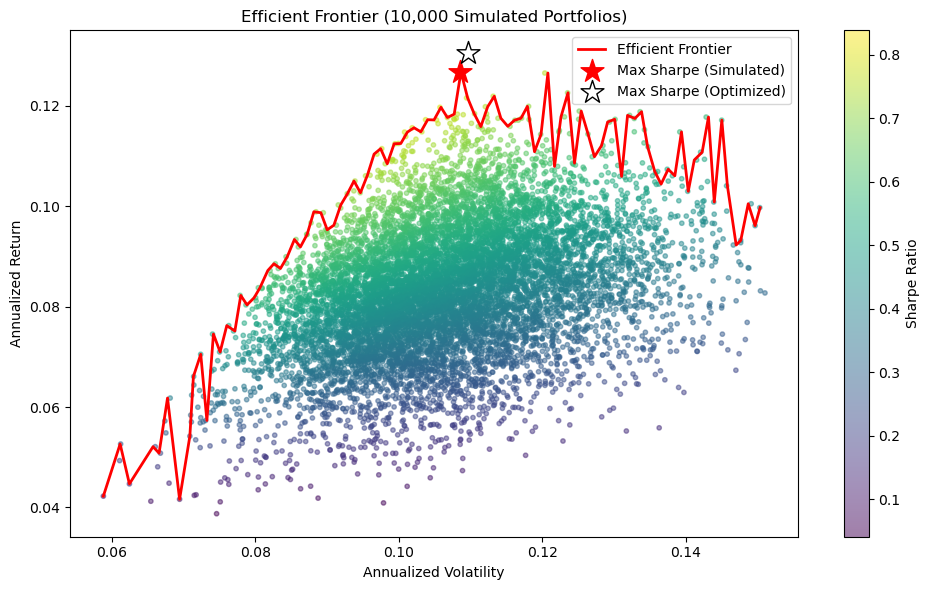

In [18]:
# Efficient frontier line
frontier_x = []
frontier_y = []

vol_bins = np.linspace(port_vols.min(), port_vols.max(), 100)

for i in range(len(vol_bins) - 1):
    mask = (port_vols >= vol_bins[i]) & (port_vols < vol_bins[i+1])
    if mask.sum() > 0:
        frontier_x.append(port_vols[mask].mean())
        frontier_y.append(port_returns[mask].max())

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(port_vols, port_returns,
                      c=port_sharpes,
                      cmap="viridis",
                      alpha=0.5,
                      s=10)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.plot(frontier_x, frontier_y,
         color="red", linewidth=2, label="Efficient Frontier")
plt.scatter(max_sharpe_vol, max_sharpe_ret,
            color="red", marker="*", s=300,
            zorder=5, label="Max Sharpe (Simulated)")
plt.scatter(opt_vol, opt_ret,
            color="white", marker="*", s=300,
            zorder=6, label="Max Sharpe (Optimized)",
            edgecolors="black", linewidths=1)
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier (10,000 Simulated Portfolios)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/efficient_frontier.png", dpi=150)
plt.show()